In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/content/KaggleV2-May-2016.csv")

print(df.head())

      PatientId  AppointmentID Gender          ScheduledDay  \
0  2.987250e+13        5642903      F  2016-04-29T18:38:08Z   
1  5.589978e+14        5642503      M  2016-04-29T16:08:27Z   
2  4.262962e+12        5642549      F  2016-04-29T16:19:04Z   
3  8.679512e+11        5642828      F  2016-04-29T17:29:31Z   
4  8.841186e+12        5642494      F  2016-04-29T16:07:23Z   

         AppointmentDay  Age      Neighbourhood  Scholarship  Hipertension  \
0  2016-04-29T00:00:00Z   62    JARDIM DA PENHA            0             1   
1  2016-04-29T00:00:00Z   56    JARDIM DA PENHA            0             0   
2  2016-04-29T00:00:00Z   62      MATA DA PRAIA            0             0   
3  2016-04-29T00:00:00Z    8  PONTAL DE CAMBURI            0             0   
4  2016-04-29T00:00:00Z   56    JARDIM DA PENHA            0             1   

   Diabetes  Alcoholism  Handcap  SMS_received No-show  
0         0           0        0             0      No  
1         0           0        0      

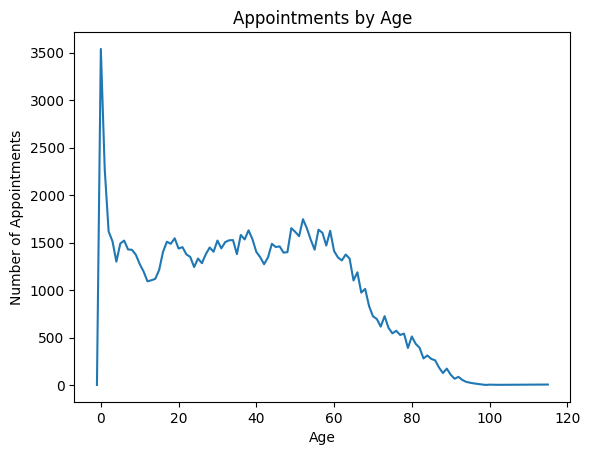

In [4]:
# Line Chart - Appointments by Age

age_counts = df["Age"].value_counts().sort_index()

plt.plot(age_counts.index, age_counts.values)

plt.title("Appointments by Age")
plt.xlabel("Age")
plt.ylabel("Number of Appointments")

plt.show()

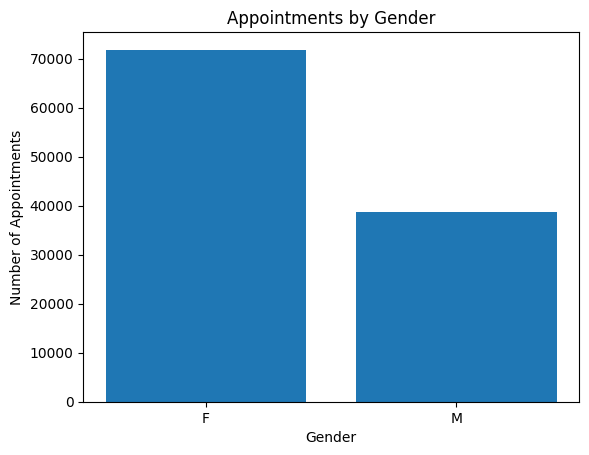

In [5]:
gender_counts = df["Gender"].value_counts()

plt.bar(gender_counts.index, gender_counts.values)

plt.title("Appointments by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Appointments")

plt.show()

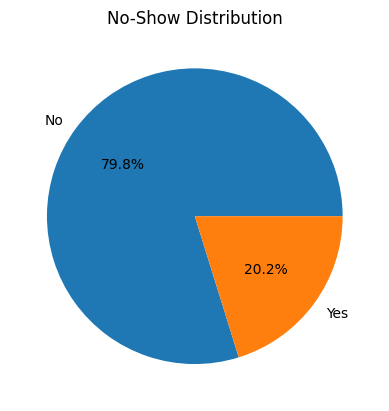

In [6]:
no_show_counts = df["No-show"].value_counts()

plt.pie(
    no_show_counts,
    labels=no_show_counts.index,
    autopct="%1.1f%%"
)

plt.title("No-Show Distribution")

plt.show()

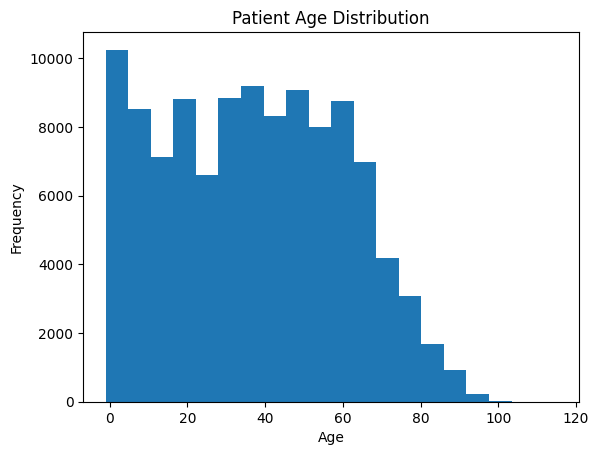

In [7]:
plt.hist(df["Age"], bins=20)

plt.title("Patient Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

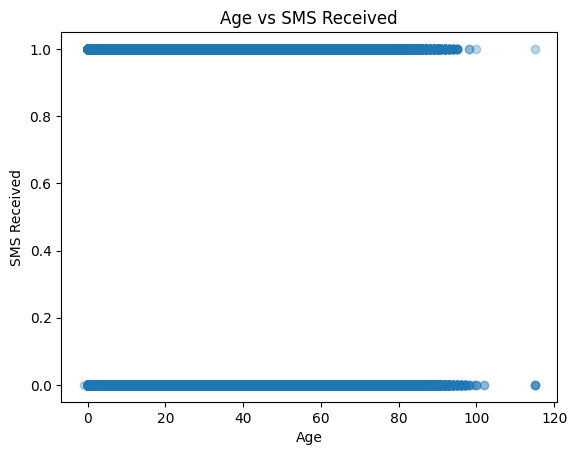

In [8]:
plt.scatter(
    df["Age"],
    df["SMS_received"],
    alpha=0.3
)

plt.title("Age vs SMS Received")
plt.xlabel("Age")
plt.ylabel("SMS Received")

plt.show()

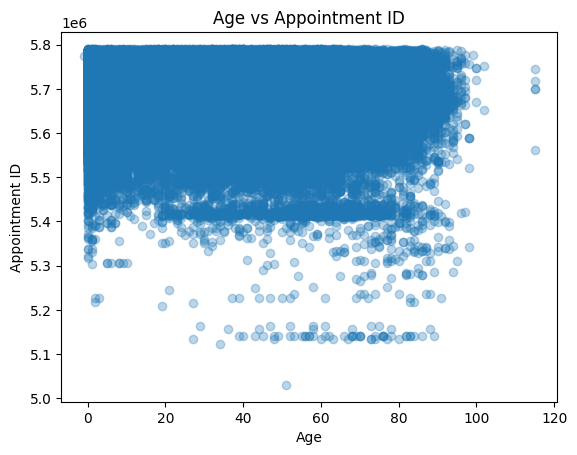

In [9]:
plt.scatter(
    df["Age"],
    df["AppointmentID"],
    alpha=0.3
)

plt.title("Age vs Appointment ID")
plt.xlabel("Age")
plt.ylabel("Appointment ID")

plt.show()

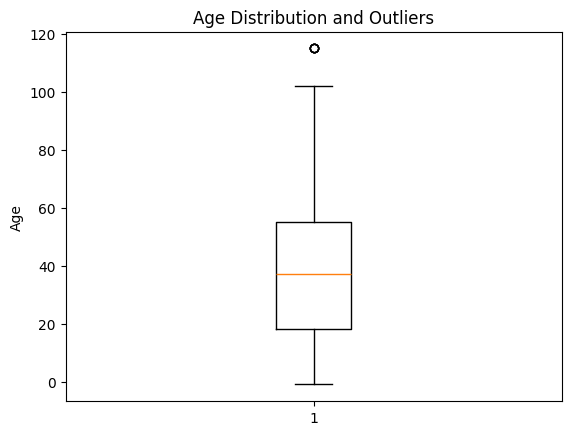

In [10]:
plt.boxplot(df["Age"])

plt.title("Age Distribution and Outliers")
plt.ylabel("Age")

plt.show()

/tmp/ipykernel_793/625687350.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


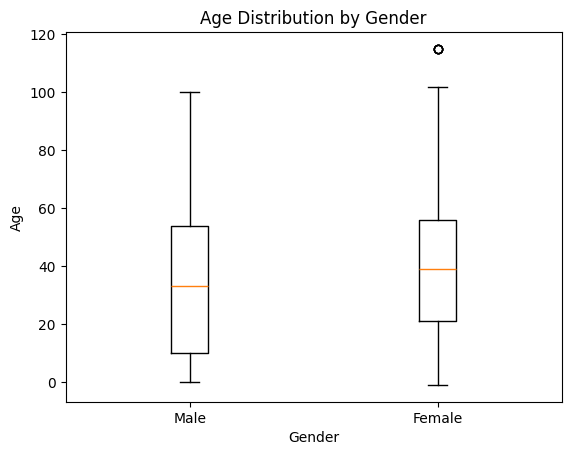

In [11]:
male_age = df[df["Gender"] == "M"]["Age"]
female_age = df[df["Gender"] == "F"]["Age"]

plt.boxplot(
    [male_age, female_age],
    labels=["Male", "Female"]
)

plt.title("Age Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Age")

plt.show()

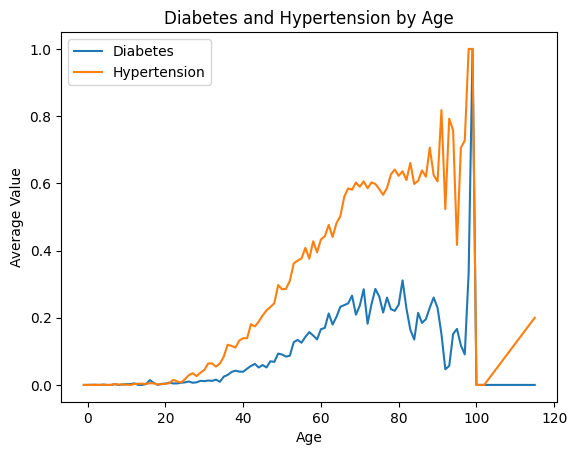

In [12]:
age_group = df.groupby("Age")[["Diabetes", "Hipertension"]].mean()

plt.plot(
    age_group.index,
    age_group["Diabetes"],
    label="Diabetes"
)

plt.plot(
    age_group.index,
    age_group["Hipertension"],
    label="Hypertension"
)

plt.title("Diabetes and Hypertension by Age")
plt.xlabel("Age")
plt.ylabel("Average Value")

plt.legend()

plt.show()

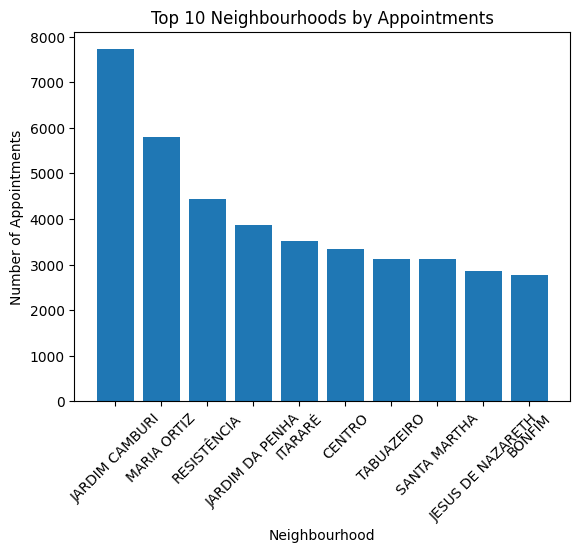

In [13]:
neighbourhood_counts = df["Neighbourhood"].value_counts().head(10)

plt.bar(
    neighbourhood_counts.index,
    neighbourhood_counts.values
)

plt.title("Top 10 Neighbourhoods by Appointments")
plt.xlabel("Neighbourhood")
plt.ylabel("Number of Appointments")

plt.xticks(rotation=45)

plt.show()

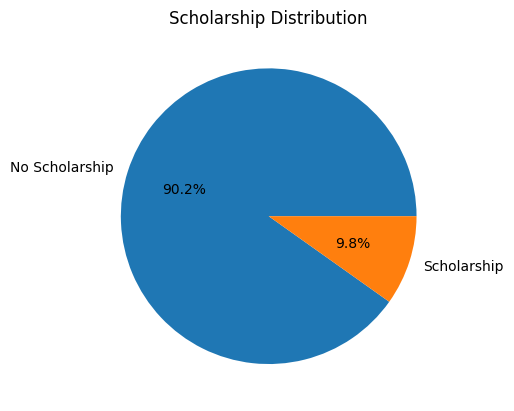

In [14]:
scholarship_counts = df["Scholarship"].value_counts()

plt.pie(
    scholarship_counts,
    labels=["No Scholarship", "Scholarship"],
    autopct="%1.1f%%"
)

plt.title("Scholarship Distribution")

plt.show()

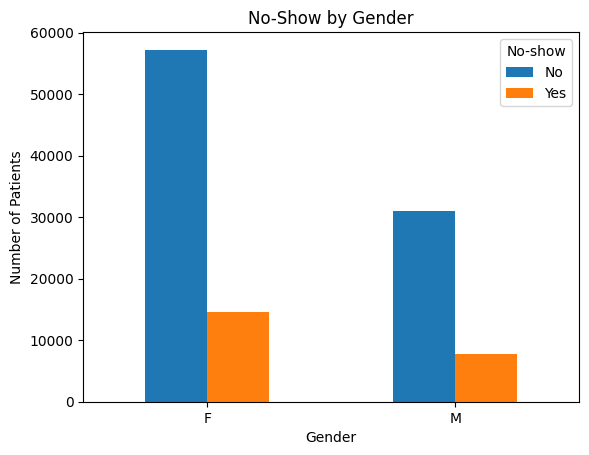

In [15]:
gender_noshow = pd.crosstab(
    df["Gender"],
    df["No-show"]
)

gender_noshow.plot(kind="bar")

plt.title("No-Show by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")

plt.xticks(rotation=0)

plt.show()

/tmp/ipykernel_793/16403283.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df.groupby(df["AppointmentDay"].dt.to_period("M"))


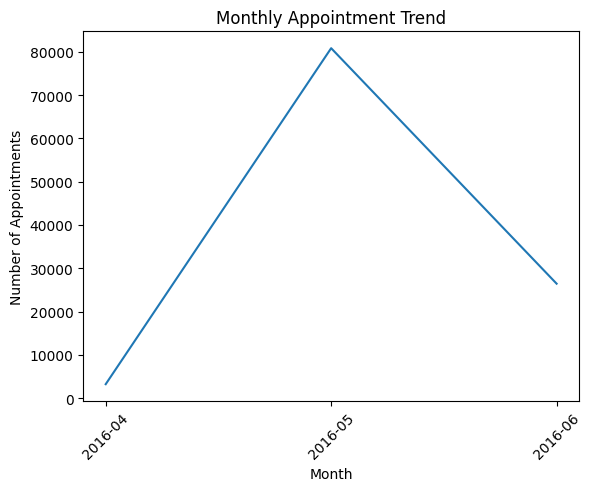

In [16]:
df["AppointmentDay"] = pd.to_datetime(df["AppointmentDay"])

monthly_appointments = (
    df.groupby(df["AppointmentDay"].dt.to_period("M"))
    .size()
)

plt.plot(
    monthly_appointments.index.astype(str),
    monthly_appointments.values
)

plt.title("Monthly Appointment Trend")
plt.xlabel("Month")
plt.ylabel("Number of Appointments")

plt.xticks(rotation=45)

plt.show()